<a href="https://colab.research.google.com/github/niranjananandan/NeuroVision-Brain-Tumor-Classification/blob/main/NeuroVision_Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/Dataset.zip'

extract_path = '/content/dataset'

print("Extracting data... Please wait!")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction Completed Successfully!")

print("Available classes (folders):", os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting data... Please wait!
Extraction Completed Successfully!
Available classes (folders): ['archive (1)']


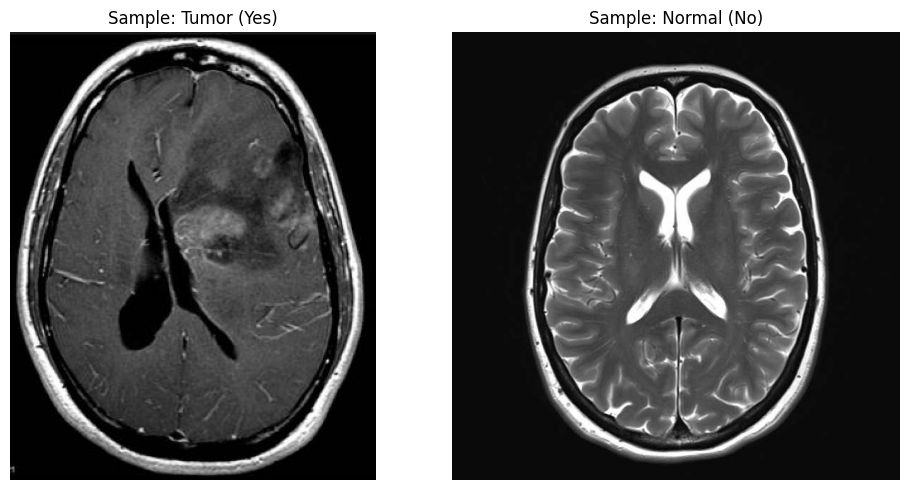

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_dir = '/content/dataset/archive (1)'
yes_path = os.path.join(base_dir, 'yes')
no_path = os.path.join(base_dir, 'no')

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

sample_yes_img = os.path.join(yes_path, yes_images[0])
sample_no_img = os.path.join(no_path, no_images[0])

img_yes = mpimg.imread(sample_yes_img)
img_no = mpimg.imread(sample_no_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_yes, cmap='gray')
axes[0].set_title('Sample: Tumor (Yes)')
axes[0].axis('off')

axes[1].imshow(img_no, cmap='gray')
axes[1].set_title('Sample: Normal (No)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

base_dir = '/content/dataset/archive (1)'
yes_path = os.path.join(base_dir, 'yes')
no_path = os.path.join(base_dir, 'no')

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

X = []
y = []
IMG_SIZE = 128

print("Data Preparation start aagudhu... Please wait!")

for img_name in yes_images:
    img_path = os.path.join(yes_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img_resized)
        y.append(1)

for img_name in no_images:
    img_path = os.path.join(no_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img_resized)
        y.append(0)\

X = np.array(X)
y = np.array(y)

X = X / 255.0

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("--------------------------------------------------")
print(f"Total images processed: {len(X)}")
print(f"Training data shape (Images): {X_train.shape}")
print(f"Testing data shape (Images): {X_test.shape}")
print("Data Preparation Successfully Completed!")
print("--------------------------------------------------")

Data Preparation start aagudhu... Please wait!
--------------------------------------------------
Total images processed: 253
Training data shape (Images): (202, 128, 128, 1)
Testing data shape (Images): (51, 128, 128, 1)
Data Preparation Successfully Completed!
--------------------------------------------------


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Building CNN Model Architecture!")

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

print("Model Building Successful!")
print("-" * 50)

model.summary()

Building CNN Model Architecture!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Building Successful!
--------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Model compiling!")
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Training Starts... GPU Processing!")
history = model.fit(X_train,
                    y_train,
                    epochs=20,
                    validation_data=(X_test, y_test),
                    batch_size=16)

print("-" * 50)
print("Model Training Successfully Completed!")

Model compiling!
Training Starts... GPU Processing!
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 342ms/step - accuracy: 0.6584 - loss: 0.5842 - val_accuracy: 0.7843 - val_loss: 0.5266
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7673 - loss: 0.5387 - val_accuracy: 0.7647 - val_loss: 0.5642
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8218 - loss: 0.4909 - val_accuracy: 0.7843 - val_loss: 0.4851
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8168 - loss: 0.4652 - val_accuracy: 0.8039 - val_loss: 0.5177
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8218 - loss: 0.4419 - val_accuracy: 0.7647 - val_loss: 0.4569
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8416 - loss: 0.3608 - val_accuracy: 0.7843 - val_loss: 0.5337
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8861 - loss: 0.3426 - val_accuracy: 0.8039 - val_loss: 0.4599
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accu

Evaluating Model Performance... Please wait!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.90      0.79      0.84        24
   Tumor (1)       0.83      0.93      0.88        27

    accuracy                           0.86        51
   macro avg       0.87      0.86      0.86        51
weighted avg       0.87      0.86      0.86        51



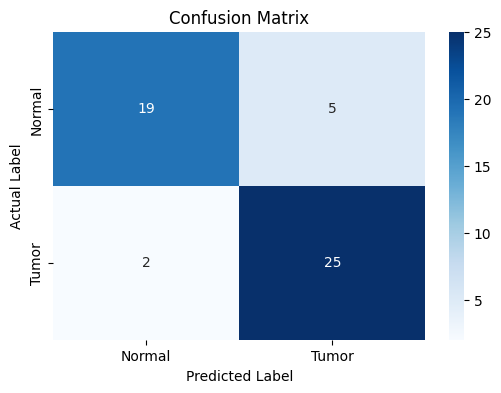

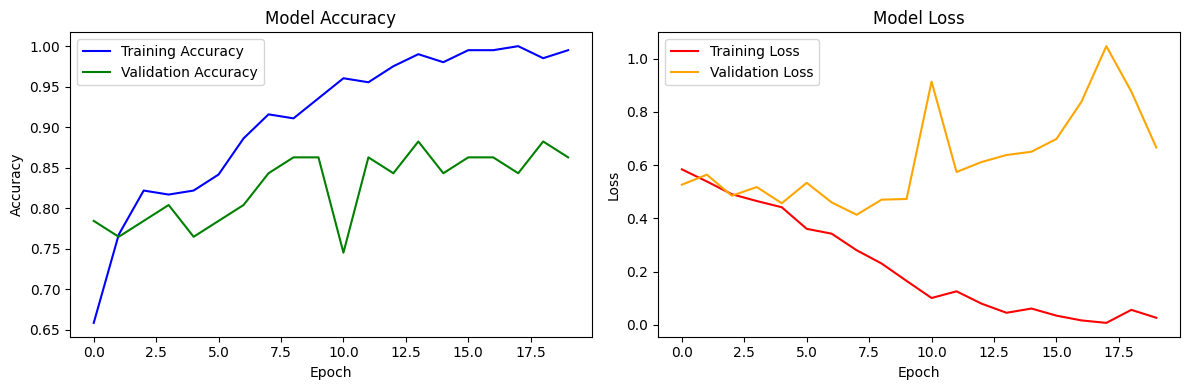

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating Model Performance... Please wait!")

y_pred_prob = model.predict(X_test)

y_pred_classes = (y_pred_prob > 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes, target_names=['Normal (0)', 'Tumor (1)']))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss', color='red')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
model.save('/content/neurovision_model.h5')
print("Model saved successfully as neurovision_model.h5!")

Model saved successfully as neurovision_model.h5!
